## Learning objectives

By the end of this lesson, you should be able to:

- Explain what geospatial data is and how it differs from ordinary tabular data.
- Load and inspect geospatial datasets using GeoPandas.
- Identify geometry types and explain the purpose of a coordinate reference system (CRS).
- Visualize geographic boundaries and point locations.
- Perform a spatial join to assign healthcare facilities to counties.
- Aggregate spatial data and create a choropleth map.
- Create an interactive map for exploring geographic patterns.

## Introduction to Geospatial Data Analysis with GeoPandas

### What is geospatial data?

Geospatial data is information associated with a specific location on or near the Earth's surface. It can describe the location of people, buildings, roads, healthcare facilities, administrative boundaries and natural features.

Throughout Python for Data Analytics, you have worked with tabular datasets containing rows and columns, such as customer records, sales transactions and student performance. These datasets help us understand what happened, but they do not always tell us where it happened.

Geospatial data introduces **location as another dimension of analysis**.

Consider a dataset of healthcare facilities in Kenya. In addition to each facility's name, type and managing agency, the dataset may contain latitude and longitude coordinates. These coordinates allow us to visualize facility locations, identify the counties in which facilities are located, and investigate geographic patterns.

With pandas, we can count healthcare facilities and summarize their characteristics. With geospatial tools, we can also connect these records to geographic boundaries and visualize the results on a map.

You already interact with geospatial data when using Google Maps to find a location, following a delivery on a map, or using GPS to navigate.

## Types of geospatial data

Geospatial data can be represented in different ways depending on the type of information being stored. Two common types are **vector data** and **raster data**.

### 1. Vector data

Vector data represents geographic features using geometric shapes such as points, lines and polygons. Each feature can also have associated attributes describing its characteristics.

Vector data is useful when analyzing distinct geographic features and their spatial relationships.

The three common vector geometry types are:

**Points**

Points represent specific geographic locations.

Examples include:

* Healthcare facilities
* Schools
* Boreholes
* Weather stations

**Lines**

Lines represent linear geographic features that have length but are generally treated as having no area.

Examples include:

* Roads
* Rivers
* Railway lines
* Electricity transmission lines

**Polygons**

Polygons represent enclosed geographic areas with boundaries.

Examples include:

* Counties
* Constituencies
* National parks
* Lakes represented by their boundaries

A feature can also consist of multiple separate parts. For example, an administrative area containing separate islands may be represented by a MultiPolygon.

### 2. Raster data

Raster data represents geographic information as a grid of cells or pixels. Each cell contains a value representing a characteristic of the area it covers.

Raster data is particularly useful for representing continuous phenomena and imagery.

Examples include:

* Satellite imagery
* Elevation models
* Land surface temperature
* Rainfall distribution
* Vegetation indices

For example, a rainfall raster can show how rainfall varies across Kenya, while satellite imagery can help us investigate land cover.

### Vector versus raster data

| Feature         | Vector data                         | Raster data                            |
| --------------- | ----------------------------------- | -------------------------------------- |
| Representation  | Points, lines and polygons          | Grid cells or pixels                   |
| Best suited for | Distinct geographic features        | Continuous surfaces and imagery        |
| Examples        | Hospitals, roads, county boundaries | Satellite imagery, rainfall, elevation |
| Common formats  | Shapefile, GeoJSON, GeoPackage      | GeoTIFF and other raster formats       |

Both types can be used together in a geospatial analysis. For example, we could use vector data to locate healthcare facilities and raster data to examine population distribution or elevation around those facilities.

## What is GeoPandas?

In this lesson, we will focus on **vector data** using GeoPandas.

GeoPandas is an open-source Python library that extends pandas to support geographic data. It allows us to work with geographic geometries alongside the tabular data we are already familiar with.

GeoPandas allows us to:

* Read and manipulate geographic datasets.
* Work with geometric types such as points, lines and polygons.
* Plot geographic features on maps.
* Perform spatial operations such as intersections and spatial joins.
* Connect tabular data to geographic boundaries.

GeoPandas builds on other Python libraries, including Shapely for geometric operations and Matplotlib for plotting.

## Understanding shapefiles

A shapefile is a common geospatial vector data format used to store geographic features and their associated attributes.

Unlike many data formats, a shapefile consists of several related files that work together to store geographic information.

Common shapefile components include:

| File extension | Purpose                                                        |
| -------------- | -------------------------------------------------------------- |
| `.shp`         | Stores the geographic geometries.                              |
| `.shx`         | Stores an index of the geometries.                             |
| `.dbf`         | Stores attribute data associated with the features.            |
| `.prj`         | Stores coordinate reference system information, when provided. |

These files typically share the same filename and are stored together in the same directory.

For example:

```text
data/
    kenya_counties.shp
    kenya_counties.shx
    kenya_counties.dbf
    kenya_counties.prj
```

The `.shp` file is the main entry point for reading the dataset, but the associated files are important for accessing the complete geographic information.

GeoPandas provides the `read_file()` function for loading shapefiles and other supported geospatial formats into a GeoDataFrame.

## Our case study: Healthcare facilities in Kenya

In this lesson, we will use two datasets:

1. **Kenya county boundaries:** vector data containing polygons representing administrative areas.
2. **Kenya healthcare facilities:** vector data containing points representing healthcare facility locations.

Our main question is:

**How are healthcare facilities distributed across Kenya's counties?**

To answer this question, we will:

* Load and inspect the geographic datasets.
* Explore county boundaries and healthcare facility locations.
* Understand geometry types and coordinate reference systems.
* Use a spatial join to identify the county containing each healthcare facility.
* Count facility records per county.
* Visualize the results using static and interactive maps.

By the end of the lesson, you will be able to use GeoPandas to explore geographic data and investigate spatial relationships using a real-world example.

### Import Libraries

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

### Load and inspect Kenya's county boundaries

#### What is a GeoDataFrame?

A `GeoDataFrame` is similar to a pandas DataFrame, but it can store geographic geometries alongside ordinary columns.

For example, a county GeoDataFrame may contain a county name, administrative information and a geometry column describing the county's shape.

In [2]:
# Load the county boundaries
#counties = gpd.read_file("data/kenya_counties.shp")

counties = gpd.read_file(
    "data/kenya_counties.shp",
    layer="ken_admin1"
)

#### Inspect the dataset

In [3]:
counties.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 22 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   adm1_name   47 non-null     str           
 1   adm1_name1  0 non-null      object        
 2   adm1_name2  0 non-null      object        
 3   adm1_name3  0 non-null      object        
 4   adm1_pcode  47 non-null     str           
 5   adm0_name   47 non-null     str           
 6   adm0_name1  0 non-null      object        
 7   adm0_name2  0 non-null      object        
 8   adm0_name3  0 non-null      object        
 9   adm0_pcode  47 non-null     str           
 10  valid_on    47 non-null     datetime64[ms]
 11  valid_to    0 non-null      datetime64[ms]
 12  area_sqkm   47 non-null     float64       
 13  version     47 non-null     str           
 14  lang        47 non-null     str           
 15  lang1       0 non-null      object        
 16  lang2       0 non-nu

In [7]:
counties.isna().sum()

adm1_name      0
adm1_name1    47
adm1_name2    47
adm1_name3    47
adm1_pcode     0
adm0_name      0
adm0_name1    47
adm0_name2    47
adm0_name3    47
adm0_pcode     0
valid_on       0
valid_to      47
area_sqkm      0
version        0
lang           0
lang1         47
lang2         47
lang3         47
adm1_ref_n     0
center_lat     0
center_lon     0
geometry       0
dtype: int64

#### Interpreting missing values

Our dataset contains several columns with missing values. In particular, ten columns have missing values in all 47 records.

Some of these columns appear to be intended for `alternative administrative names` or `language-specific values`. The valid_to column may record the date when an administrative boundary stops being valid, but no such dates are provided in this dataset.

A column containing missing values is not automatically a problem. We need to understand what the column represents and whether it is necessary for our analysis before deciding how to handle it.

For our analysis, we need the `county names` and `geographic boundaries` to map the counties and identify which county contains each healthcare facility. Since `adm1_name` and `geometry` have no missing values, we can proceed with these fields.

In [4]:
print(counties.shape)

(47, 22)


In [5]:
print(counties.columns)

Index(['adm1_name', 'adm1_name1', 'adm1_name2', 'adm1_name3', 'adm1_pcode',
       'adm0_name', 'adm0_name1', 'adm0_name2', 'adm0_name3', 'adm0_pcode',
       'valid_on', 'valid_to', 'area_sqkm', 'version', 'lang', 'lang1',
       'lang2', 'lang3', 'adm1_ref_n', 'center_lat', 'center_lon', 'geometry'],
      dtype='str')


In [8]:
counties.head()

,adm1_name,adm1_name1,adm1_name2,adm1_name3,adm1_pcode,adm0_name,adm0_name1,adm0_name2,adm0_name3,adm0_pcode,...,area_sqkm,version,lang,lang1,lang2,lang3,adm1_ref_n,center_lat,center_lon,geometry
0,Baringo,None,None,None,KE030,Kenya,None,None,None,KE,...,10889.239313,v01,en,None,None,None,Baringo,0.726352,36.018591,"POLYGON ((35.7839 1.65557, 35.78496 1.65554, 3..."
1,Bomet,None,None,None,KE036,Kenya,None,None,None,KE,...,2438.219727,v01,en,None,None,None,Bomet,-0.716095,35.238459,"POLYGON ((35.4736 -0.3992, 35.47845 -0.40663, ..."
2,Bungoma,None,None,None,KE039,Kenya,None,None,None,KE,...,3016.174229,v01,en,None,None,None,Bungoma,0.785694,34.718757,"POLYGON ((34.62017 1.10228, 34.62133 1.1016, 3..."
3,Busia,None,None,None,KE040,Kenya,None,None,None,KE,...,1811.571693,v01,en,None,None,None,Busia,0.375707,34.265111,"POLYGON ((34.36097 0.7773, 34.36172 0.77696, 3..."
4,Elgeyo-Marakwet,None,None,None,KE028,Kenya,None,None,None,KE,...,3008.391184,v01,en,None,None,None,Elgeyo-Marakwet,0.745102,35.560856,"POLYGON ((35.69818 1.28225, 35.69788 1.27905, ..."


#### Inspect the county names

In [9]:
counties["adm1_name"].head(10)

0            Baringo
1              Bomet
2            Bungoma
3              Busia
4    Elgeyo-Marakwet
5               Embu
6            Garissa
7           Homa Bay
8             Isiolo
9            Kajiado
Name: adm1_name, dtype: str

#### Count the unique county names:

In [10]:
print("Number of counties:", counties["adm1_name"].nunique())

Number of counties: 47


#### Check for missing county names:

In [11]:
print(counties["adm1_name"].isna().sum())

0


### Visualize Kenya's counties

#### Creating our first map

`GeoPandas` provides a `.plot()` method that allows us to visualize geographic features without manually specifying coordinates for every feature.

For polygon data, each polygon's shape determines what is drawn on the map.

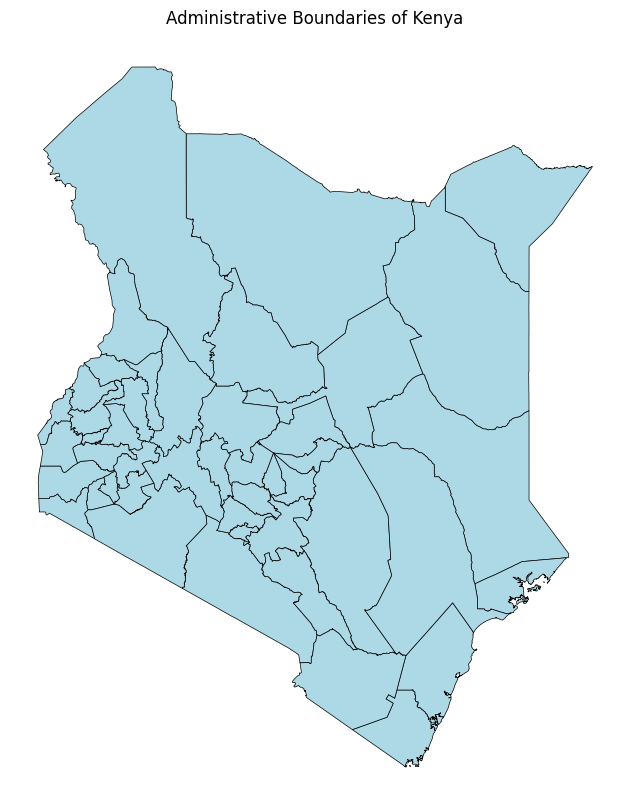

In [12]:
counties.plot(
    figsize=(10, 10),
    edgecolor="black",
    linewidth=0.5,
    facecolor="lightblue"
)

plt.title("Administrative Boundaries of Kenya")
plt.axis("off")
plt.show()

#### Filter Nairobi County

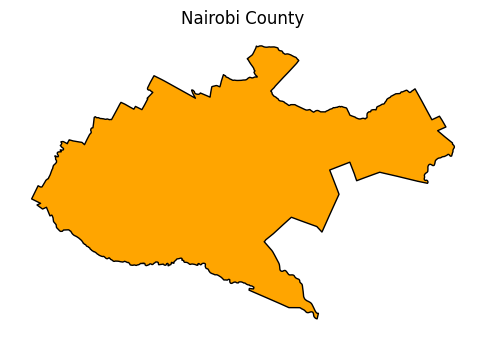

In [13]:
nairobi = counties[
    counties["adm1_name"] == "Nairobi"
]

nairobi.plot(
    figsize=(6, 6),
    edgecolor="black",
    color="orange"
)

plt.title("Nairobi County")
plt.axis("off")
plt.show()

#### Add county labels

We can annotate the map with county names. Because some polygons are irregular, `representative_point()` provides a point within each geometry that is suitable for placing a label.

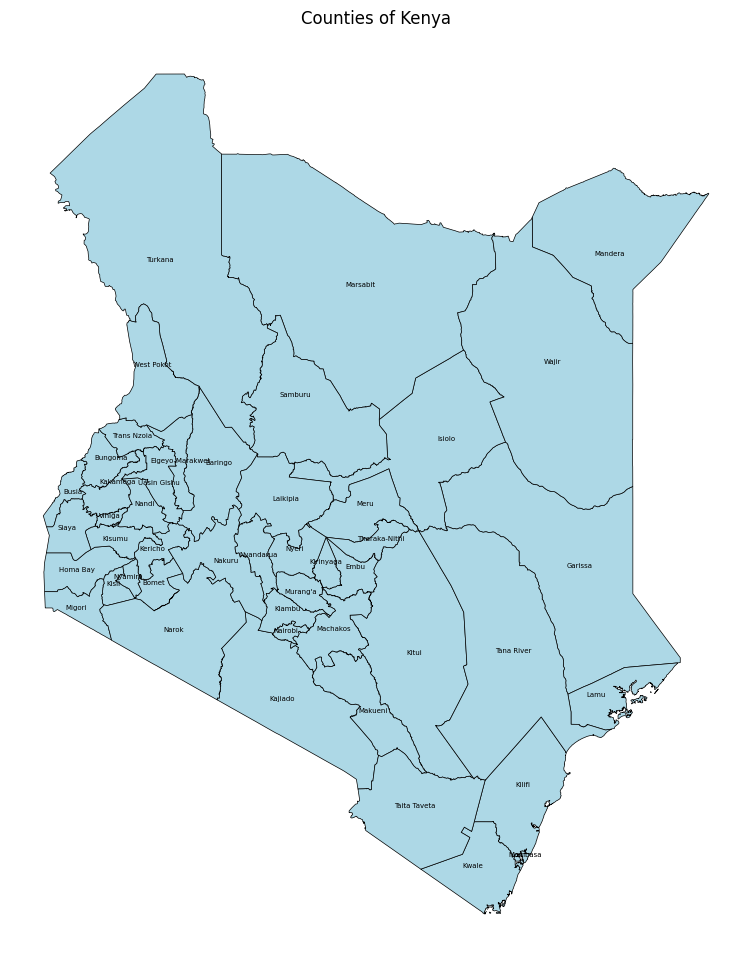

In [14]:
fig, ax = plt.subplots(figsize=(12, 12))

counties.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.5,
    facecolor="lightblue"
)

for _, row in counties.iterrows():
    point = row.geometry.representative_point()

    ax.annotate(
        text=row["adm1_name"],
        xy=(point.x, point.y),
        ha="center",
        fontsize=5
    )

ax.set_title("Counties of Kenya")
ax.axis("off")

plt.show()

### Understanding geometry and coordinate reference systems

#### What is a geometry column?

The `geometry column` stores the geographic shape or location associated with each record.

Unlike ordinary columns such as `adm1_name` or `area_sqkm`, geometry contains spatial objects that GeoPandas can plot and analyze.

In [15]:
counties[["adm1_name", "geometry"]].head()

,adm1_name,geometry
0,Baringo,"POLYGON ((35.7839 1.65557, 35.78496 1.65554, 3..."
1,Bomet,"POLYGON ((35.4736 -0.3992, 35.47845 -0.40663, ..."
2,Bungoma,"POLYGON ((34.62017 1.10228, 34.62133 1.1016, 3..."
3,Busia,"POLYGON ((34.36097 0.7773, 34.36172 0.77696, 3..."
4,Elgeyo-Marakwet,"POLYGON ((35.69818 1.28225, 35.69788 1.27905, ..."


#### Explore the types of geometry:

In [16]:
counties.geometry.geom_type.value_counts()

Polygon         44
MultiPolygon     3
Name: count, dtype: int64

### Common geometry types:

Polygon - A single enclosed area, such as a county represented by one continuous boundary.

MultiPolygon - One geographic feature made up of multiple polygon parts, such as an administrative area containing separate islands.

Point - A single geographic location, such as a healthcare facility recorded using coordinates.

In [17]:
nairobi = counties[counties["adm1_name"] == "Nairobi"]

print(nairobi.geometry.iloc[0])

POLYGON ((36.90317026800011 -1.15797710399994, 36.90542221100014 -1.1589765549999242, 36.90668106100003 -1.15925633899991, 36.90799331700009 -1.15937852899998, 36.90937423700012 -1.1592386959999317, 36.91072273300017 -1.159016071999929, 36.91162745200012 -1.1590720809999198, 36.912485123000124 -1.1592125889999352, 36.91352462800006 -1.1590989829999216, 36.91475677500017 -1.1590989829999216, 36.91579818700018 -1.1590465309999445, 36.91657638500004 -1.1591688389999604, 36.91739654500009 -1.159413575999963, 36.91823577900004 -1.1595884559999377, 36.91907501200012 -1.1598681209998745, 36.91993204700009 -1.1601769529999615, 36.920461655 -1.161711394999827, 36.920980454000016 -1.1624116299999514, 36.92217826900014 -1.1630671019999, 36.923027038999976 -1.1631021499998724, 36.92414665200016 -1.1634007389998828, 36.92494201699998 -1.164436458999944, 36.92521858200007 -1.1653658739998605, 36.925961304000054 -1.1656454799999665, 36.92700386100006 -1.166500537999866, 36.927875519000054 -1.16663324

#### Coordinate reference systems (CRS)

A `coordinate reference system (CRS)` defines how coordinates correspond to real-world locations.

A `geographic CRS` commonly represents locations using longitude and latitude in degrees. A `projected CRS` transforms geographic locations onto a flat coordinate system, often using metres.

The CRS matters because spatial operations rely on geometries being correctly positioned relative to one another.

Check the CRS of the dataset:

In [18]:
print(counties.crs)

EPSG:4326


`Geographic CRS`: coordinates are typically expressed as longitude and latitude in degrees.

`Projected CRS`: coordinates are represented on a flat map, often in metres, making them more appropriate for many distance and area calculations.

### Spatial Operations in GeoPandas

Spatial operations allow us to analyze relationships between geographic features. With GeoPandas, we can inspect geometries, calculate distances and areas, and determine how geographic features relate to one another.

In this section, we will explore the geometry types in our county dataset and use spatial predicates to identify relationships between counties.


### Calculating Area

GeoPandas allows us to calculate the area of geographic features using the `.area` attribute.

However, our county dataset uses the `EPSG:4326` coordinate reference system, which stores coordinates in longitude and latitude degrees. Calculating area directly in this CRS produces values in square degrees rather than square kilometres.

Before calculating area, we need to reproject our county boundaries from `EPSG:4326` into a projected coordinate reference system whose units are `metres`.

We will then calculate the area in square metres and convert it to square kilometres. Since one square kilometre equals one million square metres, we divide the calculated area by 1,000,000.

In [41]:
counties[["adm1_name", "area_sqkm"]].head()

,adm1_name,area_sqkm
0,Baringo,10889.239313
1,Bomet,2438.219727
2,Bungoma,3016.174229
3,Busia,1811.571693
4,Elgeyo-Marakwet,3008.391184


In [75]:
# Reproject the county geometries
counties_projected = counties.to_crs("EPSG:6933")

# Calculate area in square metres
counties_projected["area_sqm"] = counties_projected.geometry.area

# Convert area to square kilometres for easier interpretation
counties_projected["calculated_area_sqkm"] = (counties_projected["area_sqm"] / 1000000)


In [76]:
# Display the results
counties_projected[
    ["adm1_name", "area_sqm", "calculated_area_sqkm"]
].head()

,adm1_name,area_sqm,calculated_area_sqkm
0,Baringo,1.088924e+10,10889.239313
1,Bomet,2.438220e+09,2438.219727
2,Bungoma,3.016174e+09,3016.174229
3,Busia,1.811572e+09,1811.571693
4,Elgeyo-Marakwet,3.008391e+09,3008.391184


Identify the five largest and five smallest counties.

Compare the calculated area with the source area_sqkm field, if available.

Explain why calculating area directly in EPSG:4326 is inappropriate.

### Identify the Largest County Using Calculated Area

Now that we have calculated the area of each county, we can sort the results to identify the largest counties.


In [77]:
counties_projected[["adm1_name", "calculated_area_sqkm"]].sort_values(
    by="calculated_area_sqkm",
    ascending=False
).head(5)

,adm1_name,calculated_area_sqkm
24,Marsabit,76027.836393
41,Turkana,70131.758908
44,Wajir,56668.589280
6,Garissa,43596.128075
38,Tana River,39192.093113


In [46]:
counties_projected[["adm1_name", "area_sqkm"]].sort_values(
    by="area_sqkm",
    ascending=False
).head(5)

,adm1_name,area_sqkm
24,Marsabit,76027.836393
41,Turkana,70131.758908
44,Wajir,56668.589280
6,Garissa,43596.128075
38,Tana River,39192.093113


### Calculate Distance Between Counties

We can also calculate the minimum distance between county polygons. For example, we can determine which county boundaries are closest to Nairobi County's boundary.

If two counties share a boundary, their distance will be zero. This demonstrates why the `.distance()` method is useful for analyzing geographic relationships between polygons.

In [58]:
# Get Nairobi's polygon
nairobi_geometry = nairobi.geometry.iloc[0]

# Calculate each county's distance from Nairobi
counties_projected["distance_to_nairobi_km"] = (
    counties_projected.geometry.distance(nairobi_geometry) / 1000
)

counties_projected[
    ["adm1_name", "distance_to_nairobi_km"]
].sort_values(
    by="distance_to_nairobi_km"
).head(10)

,adm1_name,distance_to_nairobi_km
18,Kwale,9497.519732
37,Taita Taveta,9552.668821
27,Mombasa,9558.082962
13,Kilifi,9574.835215
9,Kajiado,9654.780172
17,Kitui,9672.677499
38,Tana River,9674.966515
22,Makueni,9679.297751
20,Lamu,9751.345633
31,Narok,9768.473987


When calculating distances across a large geographic area, we must choose an appropriate method for measuring distance.

Our county boundaries use `EPSG:4326`, which stores coordinates as longitude and latitude. Rather than projecting the entire country into one UTM zone, we can use geodesic calculations to measure distances on the Earth's surface.

In this example, we will calculate the approximate distance between the representative points of Nairobi County and every other county. A representative point is guaranteed to lie within its polygon.

In [65]:
# Get Nairobi County
nairobi = counties[counties["adm1_name"] == "Nairobi"]

# Get a point inside Nairobi
nairobi_point = nairobi.geometry.representative_point()

# Get a point inside every county
county_points = counties.copy()
county_points["geometry"] = counties.geometry.representative_point()

# Project the points
nairobi_point = nairobi_point.to_crs("EPSG:32737")
county_points = county_points.to_crs("EPSG:32737")

# Calculate distance in kilometres
county_points["distance_km"] = (
    county_points.geometry.distance(nairobi_point.iloc[0]) / 1000
)

# Display the 10 closest counties
county_points[
    ["adm1_name", "distance_km"]
].sort_values("distance_km").tail(10)

,adm1_name,distance_km
13,Kilifi,376.832328
45,West Pokot,396.677490
18,Kwale,398.897036
6,Garissa,401.919843
20,Lamu,422.126508
27,Mombasa,436.415905
24,Marsabit,470.599464
44,Wajir,504.818592
41,Turkana,521.967046
23,Mandera,661.533641


### Buffer Analysis

A `buffer` creates a zone around a geographic feature at a specified distance.

For example, we can create a 10 km buffer around Nairobi County's representative point to explore the area surrounding that location.

Buffers can be created around points, lines and polygons. The distance is measured in the units of the coordinate reference system, so we must use a suitable projected CRS when specifying a buffer in metres.

In this exercise, we will create a 10 km buffer around a point inside Nairobi County and visualize it alongside the county boundaries.

In [66]:
# Get Nairobi County
nairobi = counties[counties["adm1_name"] == "Nairobi"]

# Get a point inside Nairobi
nairobi_point = nairobi.geometry.representative_point()

# Reproject the point to a projected CRS
nairobi_point = nairobi_point.to_crs("EPSG:32737")

# Create a 10 km buffer (10,000 metres)
buffer_10km = nairobi_point.buffer(10_000)

buffer_10km

29    POLYGON ((268306.167 9856152.673, 268258.015 9...
dtype: geometry

### Visualize the Buffer

We can plot the buffer to see the circular zone around our reference point. We will also plot Nairobi County's boundary for context.

Both layers must use the same CRS for the map to display correctly.


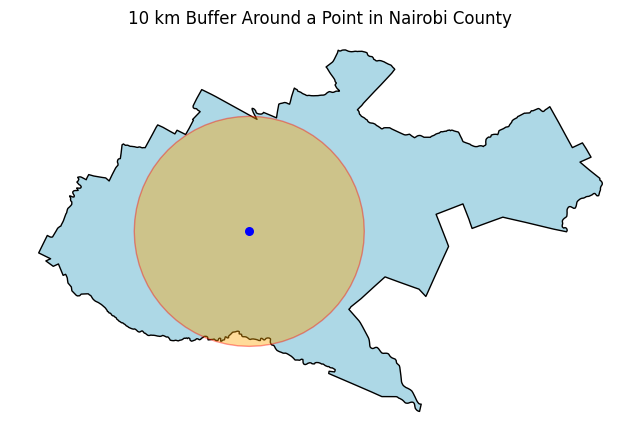

In [67]:
fig, ax = plt.subplots(figsize=(8, 8))

nairobi.to_crs("EPSG:32737").plot(
    ax=ax,
    facecolor="lightblue",
    edgecolor="black"
)

buffer_10km.plot(
    ax=ax,
    facecolor="orange",
    edgecolor="red",
    alpha=0.4
)

nairobi_point.plot(
    ax=ax,
    color="blue",
    markersize=30
)

ax.set_title("10 km Buffer Around a Point in Nairobi County")
ax.set_axis_off()

plt.show()

### Load and explore healthcare facility data

In [92]:
facilities = gpd.read_file("data/kenya_health.shp")

#### Data Inspection

In [93]:
facilities.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 3175 entries, 0 to 3174
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   FNO         2929 non-null   float64 
 1   F_NAME      3175 non-null   str     
 2   HMIS_       2566 non-null   float64 
 3   PROV        3175 non-null   str     
 4   DIST        3175 non-null   str     
 5   DIVISION    2979 non-null   str     
 6   LOCATION    2925 non-null   str     
 7   SUB_LOCATI  2910 non-null   str     
 8   LONG        2837 non-null   float64 
 9   LAT         2837 non-null   float64 
 10  SPATIAL_RE  2837 non-null   str     
 11  F_TYPE      3175 non-null   int32   
 12  AGENCY      3175 non-null   str     
 13  N14         0 non-null      object  
 14  N15         0 non-null      object  
 15  geometry    2837 non-null   geometry
dtypes: float64(4), geometry(1), int32(1), object(2), str(8)
memory usage: 591.0+ KB


In [94]:
print("\nGeometry types:")
print(facilities.geometry.geom_type.value_counts())


Geometry types:
Point    2837
Name: count, dtype: int64


In [95]:
facilities.isna().sum()

FNO            246
F_NAME           0
HMIS_          609
PROV             0
DIST             0
DIVISION       196
LOCATION       250
SUB_LOCATI     265
LONG           338
LAT            338
SPATIAL_RE     338
F_TYPE           0
AGENCY           0
N14           3175
N15           3175
geometry       338
dtype: int64

In [96]:
facilities.isnull().sum() / len(facilities) * 100

FNO             7.748031
F_NAME          0.000000
HMIS_          19.181102
PROV            0.000000
DIST            0.000000
DIVISION        6.173228
LOCATION        7.874016
SUB_LOCATI      8.346457
LONG           10.645669
LAT            10.645669
SPATIAL_RE     10.645669
F_TYPE          0.000000
AGENCY          0.000000
N14           100.000000
N15           100.000000
geometry       10.645669
dtype: float64

#### Investigate Missing Values

In [97]:
# Check whether the missing values occur in the same records
spatial_columns = ["LONG", "LAT", "SPATIAL_RE", "geometry"]

facilities[spatial_columns].isna().sum()

LONG          338
LAT           338
SPATIAL_RE    338
geometry      338
dtype: int64

In [98]:
# Check whether those facilities have other useful information
facilities.loc[
    facilities.geometry.isna(),
    ["F_NAME", "F_TYPE", "AGENCY", "PROV", "DIST", "LOCATION"]
].head(10)

,F_NAME,F_TYPE,AGENCY,PROV,DIST,LOCATION
80,GATITHI DISP,4,MISS,CENTRAL,KIRINYAGA,KERUGOYA
91,KAGUMO LIFE GIVING DISP,4,MISS,CENTRAL,KIRINYAGA,MUTIRA
97,KARIRA HOSPITAL,1,MISS,CENTRAL,KIRINYAGA,NaN
112,KIUMBU DISP,4,MISS,CENTRAL,KIRINYAGA,INOI
115,MAGDALENE ACK DISP,4,MISS,CENTRAL,KIRINYAGA,NGARIAMA
118,MT KENYA EAST ACK DISP,4,MISS,CENTRAL,KIRINYAGA,NGARIAMA
125,MUTITHI DISP,4,MOH,CENTRAL,KIRINYAGA,TEBERE
127,NGARIAMA DISP,4,MOH,CENTRAL,KIRINYAGA,MUTITHI
135,ST LUKES MURIGARIGA DISP,4,MISS,CENTRAL,KIRINYAGA,NaN
136,ST TERESA DISP,4,MOH,CENTRAL,KIRINYAGA,MUTITHI


#### how to handle missing values

- For spatial analysis: Exclude records without usable geometry from the spatial join, while retaining the original dataset.

- For general facility analysis: Keep them if their other fields are useful, for example when analysing facility types or agencies.

#### for spatial analysis:

In [99]:
facilities = facilities.dropna(subset=["geometry"]).copy()

In [100]:
# Then check how many records remain:
print(facilities.shape)
print(facilities.geometry.isna().sum())

(2837, 16)
0


In [101]:
# Duplicate rows:
facilities.duplicated().sum()

np.int64(0)

In [102]:
facilities.head()

,FNO,F_NAME,HMIS_,PROV,DIST,DIVISION,LOCATION,SUB_LOCATI,LONG,LAT,SPATIAL_RE,F_TYPE,AGENCY,N14,N15,geometry
0,1.0,ANMER DISP,190.0,CENTRAL,KIAMBU,KIAMBAA,KAMITI,ANMER,36.84009,-1.137387,1:50000 MAPS,4,MOH,None,None,POINT (36.84009 -1.13739)
1,2.0,BATHI DISP,192.0,CENTRAL,KIAMBU,LARI,KIJABE,BATHI,36.63470,-0.978523,DDP,4,MISS,None,None,POINT (36.6347 -0.97852)
2,3.0,BIBIRIONI DISP,3731.0,CENTRAL,KIAMBU,LIMURU,LIMURU,BIBIRIONI,36.61710,-1.081080,1:50000 MAPS,4,MISS,None,None,POINT (36.6171 -1.08108)
3,4.0,CHURA DISP,NaN,CENTRAL,KIAMBU,KIKUYU,KABETE,CHURA,36.68960,-1.216350,1:50000 MAPS,4,MOH,None,None,POINT (36.6896 -1.21635)
4,5.0,CIANDA DISP,193.0,CENTRAL,KIAMBU,KIAMBAA,CIANDA,CIANDA,36.76130,-1.132800,1:50000 MAPS,4,MOH,None,None,POINT (36.7613 -1.1328)


#### Check whether the facilities and county boundaries use the same CRS:

In [103]:
print("Facilities CRS:", facilities.crs)
print("Counties CRS:", counties.crs)

Facilities CRS: EPSG:4326
Counties CRS: EPSG:4326


## Understand the healthcare dataset

In [104]:
facilities[
    ["F_NAME", "PROV", "DIST", "LOCATION",
     "F_TYPE", "AGENCY", "LONG", "LAT"]
].head(10)

,F_NAME,PROV,DIST,LOCATION,F_TYPE,AGENCY,LONG,LAT
0,ANMER DISP,CENTRAL,KIAMBU,KAMITI,4,MOH,36.840090,-1.137387
1,BATHI DISP,CENTRAL,KIAMBU,KIJABE,4,MISS,36.634700,-0.978523
2,BIBIRIONI DISP,CENTRAL,KIAMBU,LIMURU,4,MISS,36.617100,-1.081080
3,CHURA DISP,CENTRAL,KIAMBU,KABETE,4,MOH,36.689600,-1.216350
4,CIANDA DISP,CENTRAL,KIAMBU,CIANDA,4,MOH,36.761300,-1.132800
5,GACHOIRE DISP,CENTRAL,KIAMBU,NYANDUMA,4,MOH,36.704400,-0.991187
6,GATHANGA DISP,CENTRAL,KIAMBU,WAGUTHU,4,MOH,36.791234,-1.182312
7,GATHANGARI DISP,CENTRAL,KIAMBU,GITHIGA,4,MOH,36.705400,-1.068020
8,GIATHIEKO DISP,CENTRAL,KIAMBU,IKINU,4,MOH,36.827900,-1.098830
9,GICHARANI DISP,CENTRAL,KIAMBU,KARAI,4,MISS,36.650000,-1.270000


### Plot the healthcare facility locations

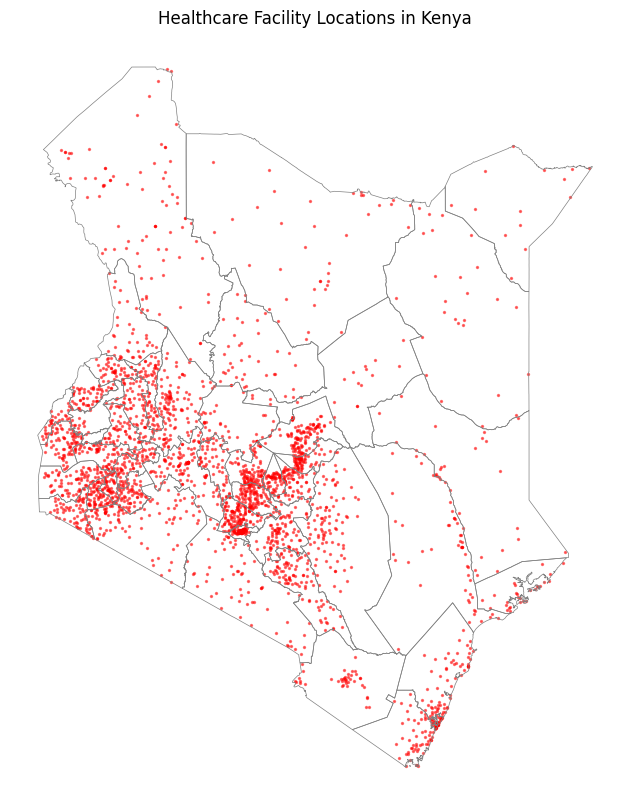

In [105]:
fig, ax = plt.subplots(figsize=(10, 10))

counties.boundary.plot(
    ax=ax,
    color="grey",
    linewidth=0.5
)

facilities.plot(
    ax=ax,
    color="red",
    markersize=2,
    alpha=0.5
)

ax.set_title("Healthcare Facility Locations in Kenya")
ax.axis("off")

plt.show()

### Find Healthcare Facilities Within 10 km

Buffers are especially useful for proximity analysis. We can check which healthcare facilities fall inside the 10 km buffer.

We will reproject the healthcare facilities to the same CRS, then use within() to identify the facilities inside the buffer.

In [106]:
facilities_projected = facilities.to_crs("EPSG:32737")

facilities_within_10km = facilities_projected[
    facilities_projected.geometry.within(buffer_10km.iloc[0])
]

facilities_within_10km[
    ["F_NAME", "F_TYPE"]
].head(10)

,F_NAME,F_TYPE
1428,AYANY ESTATE HEALTH CENTRE,3
1429,BABA DOGO HEALTH CENTRE,3
1430,BAHATI DISP,4
1431,BAHATI HEALTH CENTRE,3
1434,BORAH ROAD DISP,4
1437,CALIFORNIA HC,3
1438,CATHOLIC DISP,4
1439,CHARLES NEW ROAD HC,3
1443,CRESCENT MEDICAL AID EASTLEIGH,4
1444,CRESCENT MEDICAL AID MUKURU,4


### Count healthcare facilities in each county

The county boundaries use `adm1_name`, but the facility dataset has no obvious county-name column. Since it contains geographic points, this is an ideal use case for a `spatial join`.

First, inspect the geometry types to confirm that the facilities are points and the counties are polygons.

In [107]:
print(facilities.geometry.geom_type.value_counts())
print(counties.geometry.geom_type.value_counts())

Point    2837
Name: count, dtype: int64
Polygon         44
MultiPolygon     3
Name: count, dtype: int64


#### Perform a spatial join

A `spatial join` connects records based on their geographic relationship. Here, we'll identify the county containing each healthcare facility.

In [115]:
facilities_by_county = gpd.sjoin(
    facilities,
    counties[["adm1_name", "geometry"]],
    how="left",
    predicate="within"
)

facilities_by_county[
  ["F_NAME", "F_TYPE", "AGENCY", "adm1_name"]
].head()

,F_NAME,F_TYPE,AGENCY,adm1_name
0,ANMER DISP,4,MOH,Kiambu
1,BATHI DISP,4,MISS,Kiambu
2,BIBIRIONI DISP,4,MISS,Kiambu
3,CHURA DISP,4,MOH,Kiambu
4,CIANDA DISP,4,MOH,Kiambu


- `how="left"` keeps all healthcare facilities, even if some don't match a county.

- `predicate="within"` checks whether each facility point falls inside a county polygon.

- `adm1_name` contains the county names in your boundaries dataset.

#### Count facilities per county

In [116]:
facility_counts = (
    facilities_by_county
    .groupby("adm1_name")
    .size()
    .reset_index(name="facility_count")
    .sort_values("facility_count", ascending=False)
)

facility_counts.head(10)

,adm1_name,facility_count
12,Kiambu,110
25,Meru,106
0,Baringo,105
30,Nakuru,99
28,Murang'a,98
17,Kitui,92
32,Narok,92
35,Nyeri,90
29,Nairobi,89
22,Makueni,89


In [121]:
unmatched = facilities_by_county[
    facilities_by_county["adm1_name"].isna()
].copy()

In [122]:
unmatched.shape[0]

4

#### Inspect the unmatched facilities

In [123]:
unmatched = facilities_by_county[
    facilities_by_county["adm1_name"].isna()
]

unmatched[["F_NAME", "F_TYPE", "AGENCY", "LONG", "LAT"]]

,F_NAME,F_TYPE,AGENCY,LONG,LAT
514,VANGA H C,3,MOH,39.217396,-4.660974
527,KIUNGA HEALTH CENTRE,3,MOH,41.489472,-1.741314
2836,AIC KIBISH DISP,4,MISS,35.828016,5.352924
2871,KIBISH DISP,4,MOH,35.779489,5.387024


The unmatched results may indicate an issue with the county boundary data, the point locations, or how the geometries overlap.

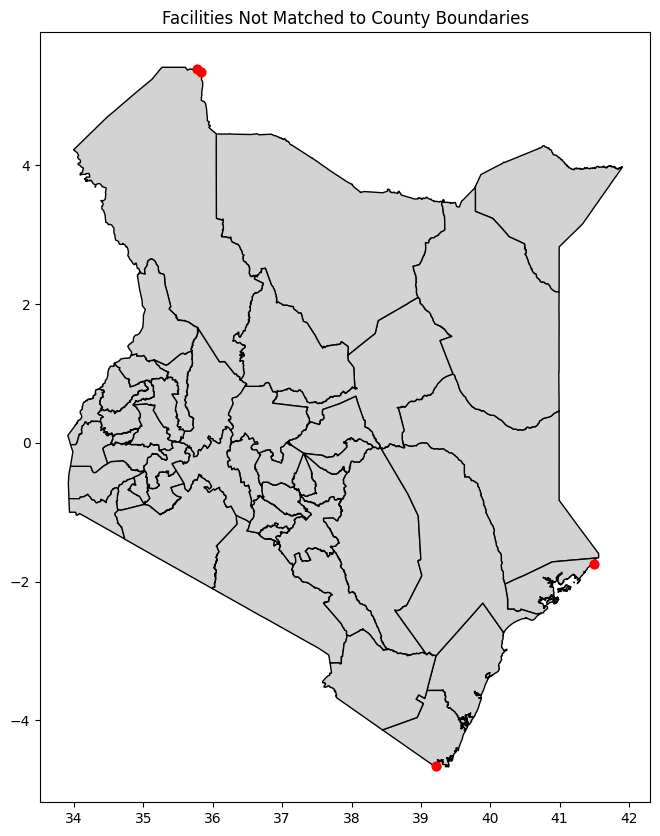

In [124]:
fig, ax = plt.subplots(figsize=(10, 10))

counties.plot(ax=ax, facecolor="lightgrey", edgecolor="black")

unmatched.plot(ax=ax, color="red", markersize=40)

plt.title("Facilities Not Matched to County Boundaries")
plt.show()

#### check the distances to the nearest county

In [128]:
# Project both datasets
counties_projected = counties.to_crs("EPSG:32737")
unmatched_projected = unmatched.to_crs("EPSG:32737")

# Remove the previous join's index column from the temporary copy
unmatched_projected = unmatched_projected.drop(
    columns=["index_right"], errors="ignore"
)

# Find the nearest county
nearest = gpd.sjoin_nearest(
    unmatched_projected,
    counties_projected[["adm1_name", "geometry"]],
    how="left",
    distance_col="distance_m"
)

# Display distances in kilometres
nearest["distance_km"] = nearest["distance_m"] / 1000

nearest[
    ["F_NAME", "adm1_name_right", "distance_m", "distance_km"]
].round(3)

,F_NAME,adm1_name_right,distance_m,distance_km
514,VANGA H C,Kwale,70.102,0.070
527,KIUNGA HEALTH CENTRE,Lamu,2345.544,2.346
2836,AIC KIBISH DISP,Turkana,752.116,0.752
2871,KIBISH DISP,Turkana,3015.378,3.015


In [134]:
# Assign each unmatched facility to its nearest county
nearest_county = nearest.set_index("F_NAME")["adm1_name_right"]

facilities_by_county.loc[
    facilities_by_county["adm1_name"].isna(),
    "adm1_name"
] = (
    facilities_by_county.loc[
        facilities_by_county["adm1_name"].isna(), "F_NAME"
    ].map(nearest_county)
)

In [135]:
print(
    "Facilities still unmatched:",
    facilities_by_county["adm1_name"].isna().sum()
)

Facilities still unmatched: 0


#### Visualize the results

Merge the counts into the county GeoDataFrame, then plot a choropleth map.

In [136]:
county_map = counties.merge(
    facility_counts,
    on="adm1_name",
    how="left"
)

county_map["facility_count"] = (
    county_map["facility_count"].fillna(0)
)

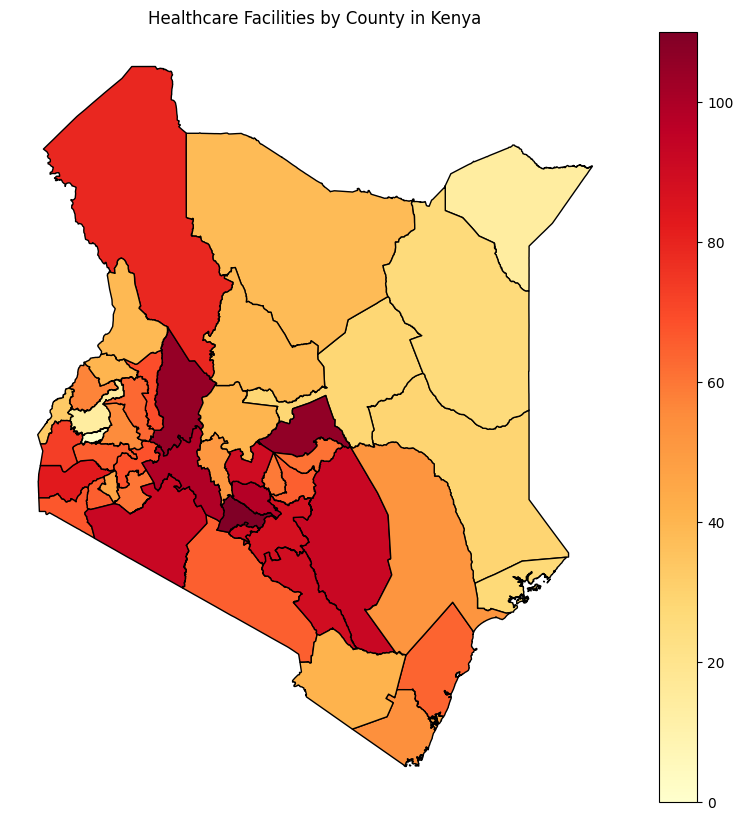

In [137]:
county_map.plot(
    column="facility_count",
    legend=True,
    figsize=(10, 10),
    edgecolor="black",
    cmap="YlOrRd",
    missing_kwds={"color": "lightgrey"}
)

plt.title("Healthcare Facilities by County in Kenya")
plt.axis("off")
plt.show()


### Interactive mapping

`%pip install folium mapclassify`

In [74]:
m = county_map.explore(
    column="facility_count",
    cmap="YlOrRd",
    legend=True,
    tooltip=["adm1_name", "facility_count"],
    tiles="OpenStreetMap"
)

m